In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

titanic_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

for col in titanic_data.columns:
    if titanic_data[col].isna().any():
        print(col, titanic_data[col].isna().sum())

LotFrontage 259
Alley 1369
MasVnrType 872
MasVnrArea 8
BsmtQual 37
BsmtCond 37
BsmtExposure 38
BsmtFinType1 37
BsmtFinType2 38
Electrical 1
FireplaceQu 690
GarageType 81
GarageYrBlt 81
GarageFinish 81
GarageQual 81
GarageCond 81
PoolQC 1453
Fence 1179
MiscFeature 1406


In [2]:
categorical_cols = titanic_data.select_dtypes(include='object').columns

print("Categorical Columns and their properties:")
print("-------------------------------------------")
for col in categorical_cols:
    print(f"Column: {col}")
    print(f"  Number of unique values: {titanic_data[col].nunique()}")
    print(f"  Missing values: {titanic_data[col].isna().sum()} ({titanic_data[col].isna().sum() / len(titanic_data):.2%})")

    # Calculate mean SalePrice for each category
    if titanic_data[col].nunique() < 50: # Limit for readability
        mean_sale_price_by_category = titanic_data.groupby(col)['SalePrice'].mean().sort_values(ascending=False)
        print(f"  Mean SalePrice by category:\n{mean_sale_price_by_category.to_string()}")
    else:
        print(f"  (Too many unique values to display mean SalePrice by category here: {titanic_data[col].nunique()})")
    print("\n")

Categorical Columns and their properties:
-------------------------------------------
Column: MSZoning
  Number of unique values: 5
  Missing values: 0 (0.00%)
  Mean SalePrice by category:
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000


Column: Street
  Number of unique values: 2
  Missing values: 0 (0.00%)
  Mean SalePrice by category:
Street
Pave    181130.538514
Grvl    130190.500000


Column: Alley
  Number of unique values: 2
  Missing values: 1369 (93.77%)
  Mean SalePrice by category:
Alley
Pave    168000.585366
Grvl    122219.080000


Column: LotShape
  Number of unique values: 4
  Missing values: 0 (0.00%)
  Mean SalePrice by category:
LotShape
IR2    239833.365854
IR3    216036.500000
IR1    206101.665289
Reg    164754.818378


Column: LandContour
  Number of unique values: 4
  Missing values: 0 (0.00%)
  Mean SalePrice by category:
LandContour
HLS    231533.940000
Low    203661.111111
Lv

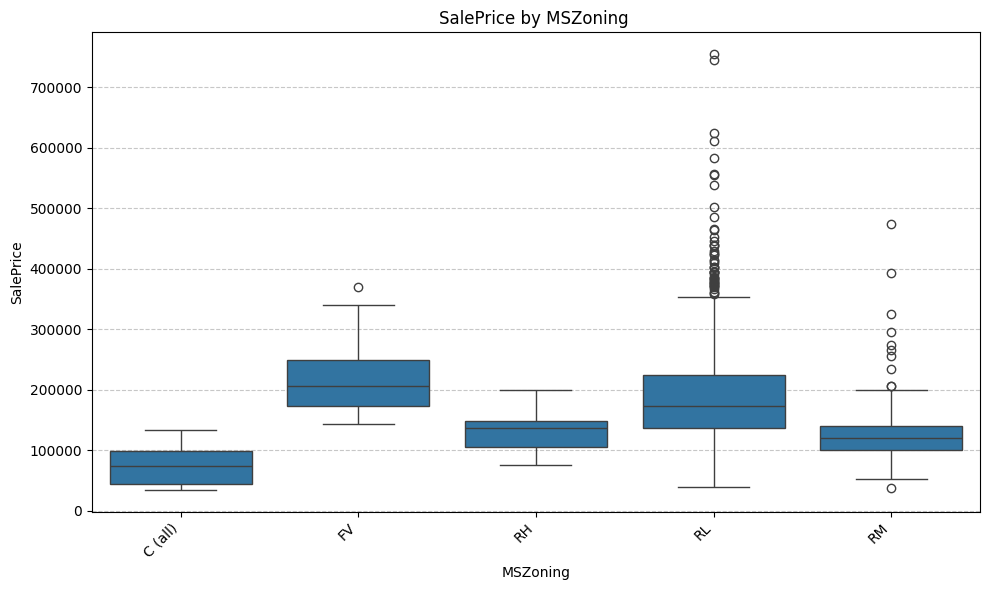

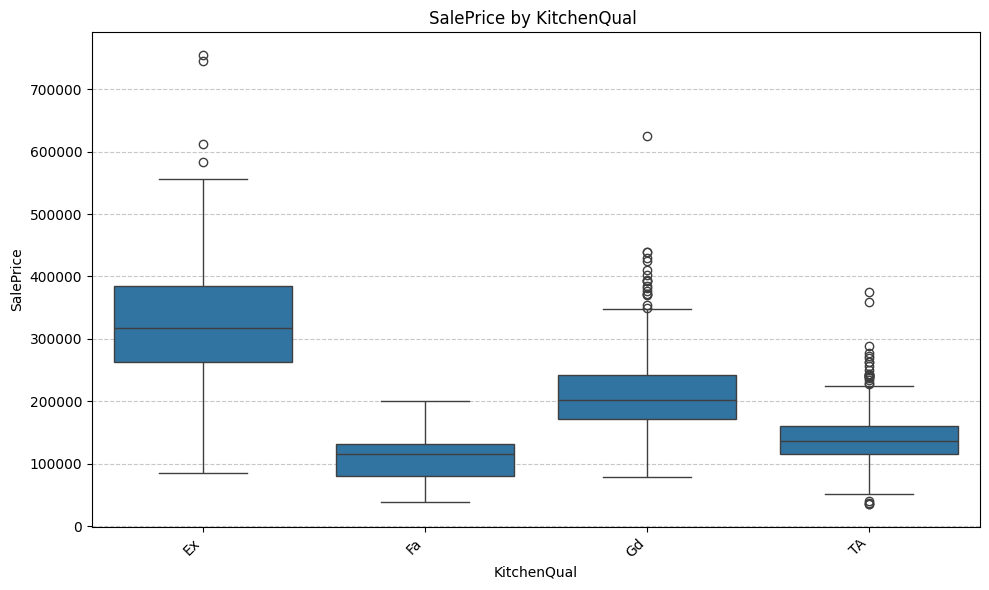

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting function for categorical features vs SalePrice
def plot_categorical_vs_target(df, feature, target='SalePrice', title_suffix=''):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=feature, y=target, data=df.sort_values(by=feature))
    plt.title(f'SalePrice by {feature} {title_suffix}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example 1: MSZoning
plot_categorical_vs_target(titanic_data, 'MSZoning')

# Example 2: KitchenQual
plot_categorical_vs_target(titanic_data, 'KitchenQual')


In [4]:
import seaborn as sns

numeric_data = titanic_data.select_dtypes(include='number')
corr_with_target = numeric_data.corr()['SalePrice']
corr_sorted = corr_with_target.sort_values(ascending=False)
# print(corr_sorted)
threshold = 0.3

high_corr = corr_sorted[abs(corr_sorted) >= threshold]
print(high_corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
Name: SalePrice, dtype: float64


In [5]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd

features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd",
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MasVnrArea",
    "Fireplaces", "BsmtFinSF1", "LotFrontage", "WoodDeckSF",
    "2ndFlrSF", "OpenPorchSF","SalePrice"
]

X = titanic_data[[col for col in features if col != 'SalePrice']]
y = titanic_data['SalePrice']
y_binned = pd.cut(y, bins=5, labels=False, include_lowest=True)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_indices, test_indices in split.split(X, y_binned):
    strat_train_set = titanic_data.loc[train_indices]
    strat_test_set = titanic_data.loc[test_indices]

In [6]:
high_missing_categorical_cols = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']

print(f"Dropping columns: {high_missing_categorical_cols}")
titanic_data.drop(columns=high_missing_categorical_cols, inplace=True, errors='ignore')

print("Columns dropped successfully. Remaining columns:")
print(titanic_data.columns.tolist())

Dropping columns: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Columns dropped successfully. Remaining columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'Paved

Generating box plots for SalePrice vs. selected categorical features...


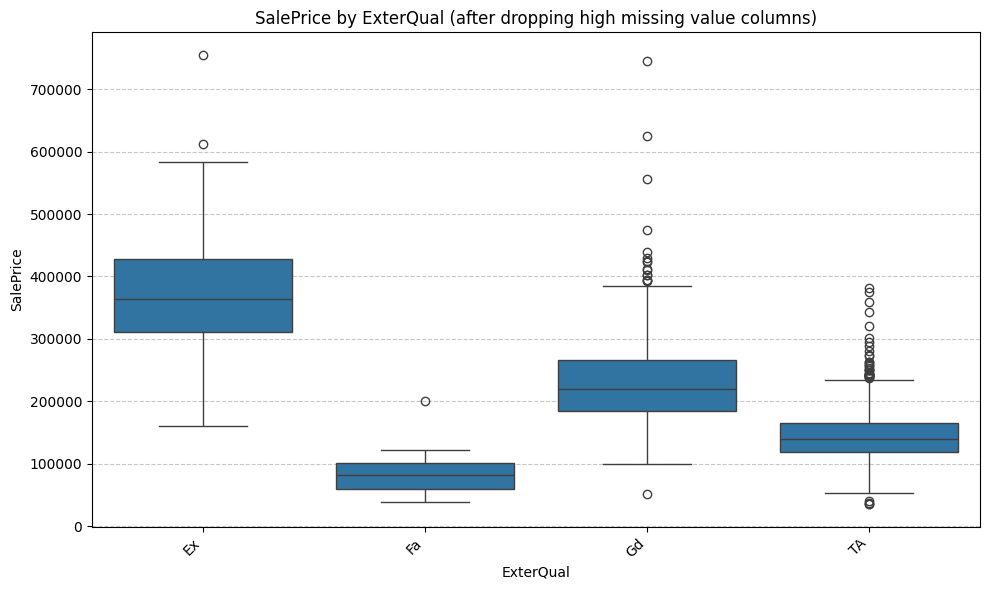

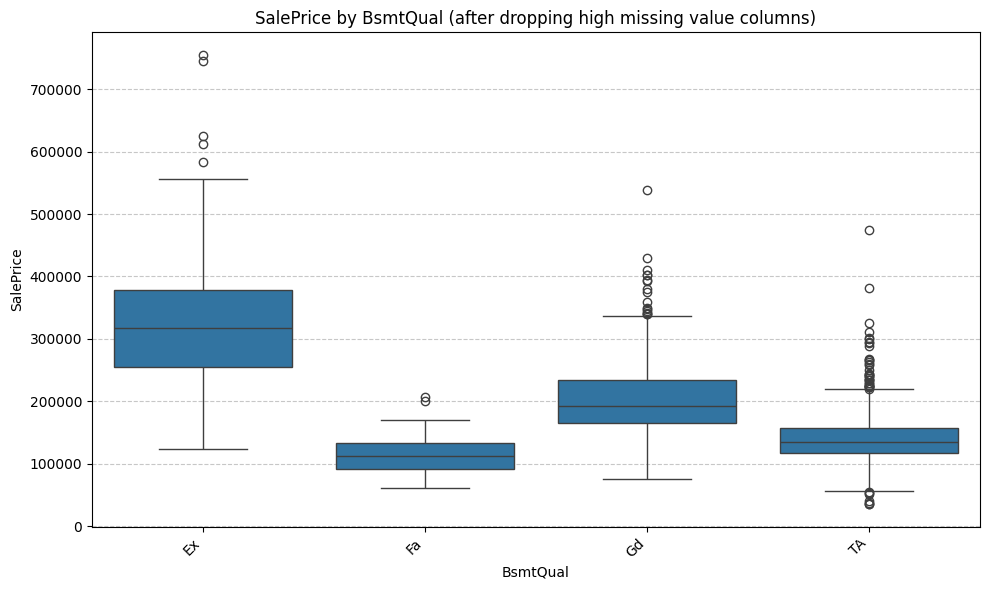

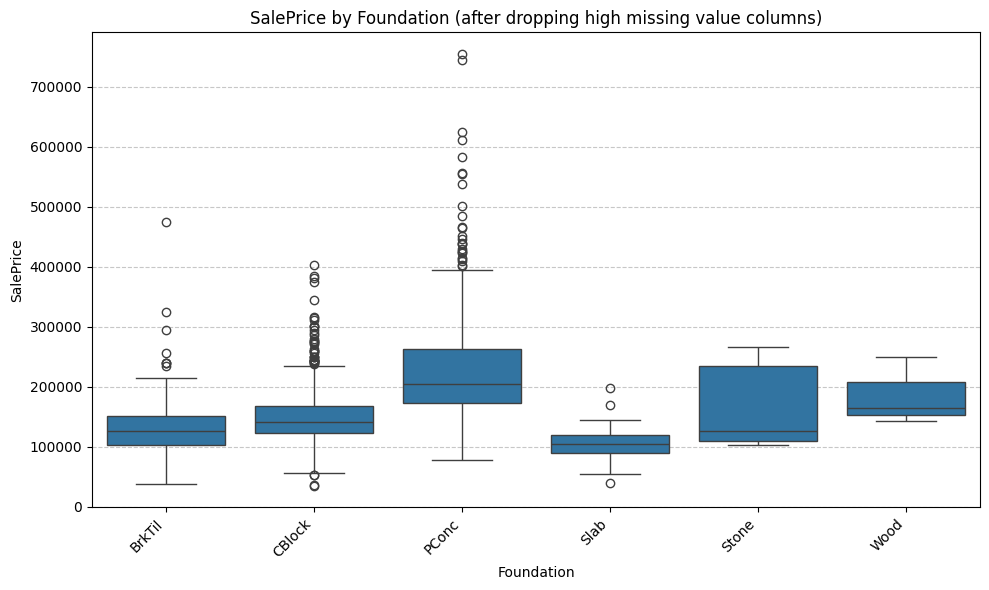

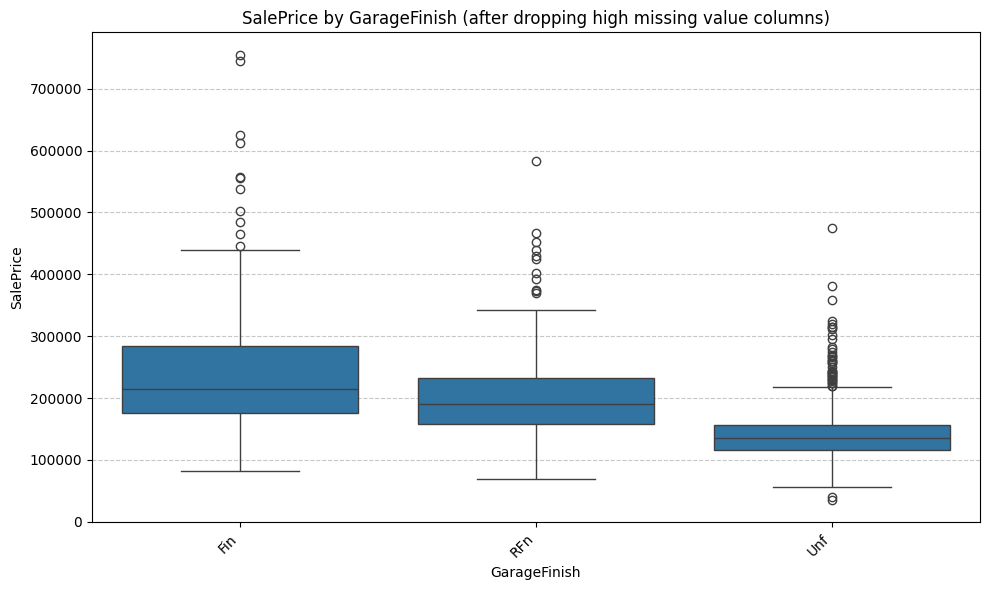

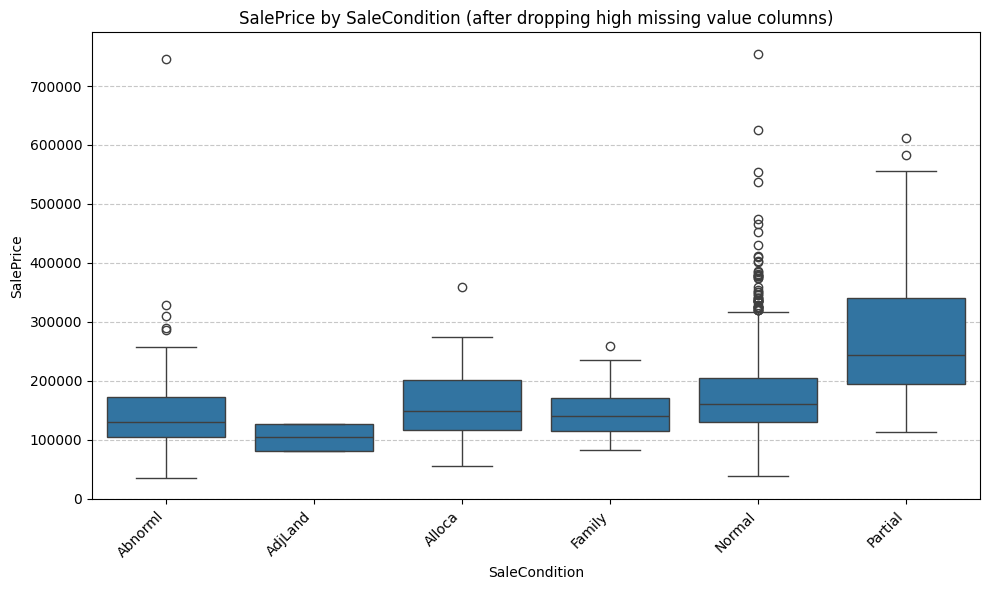

In [7]:
features_to_plot = ['ExterQual', 'BsmtQual', 'Foundation', 'GarageFinish', 'SaleCondition']

print("Generating box plots for SalePrice vs. selected categorical features...")
for feature in features_to_plot:
    plot_categorical_vs_target(titanic_data, feature, title_suffix='(after dropping high missing value columns)')

In [8]:
categorical_cols_with_missing_values = titanic_data.select_dtypes(include='object').columns[titanic_data.select_dtypes(include='object').isna().any()].tolist()
print(f"Categorical columns with missing values: {categorical_cols_with_missing_values}")

Categorical columns with missing values: ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


In [9]:
cols_indicating_absence = [
    'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]

# Impute columns where NaN indicates absence with 'None'
for col in cols_indicating_absence:
    if col in titanic_data.columns and titanic_data[col].isna().any():
        titanic_data[col] = titanic_data[col].fillna('None')
        print(f"Imputed missing values in '{col}' with 'None'.")

# Identify any other remaining categorical columns with missing values
# (After dropping high missing value cols and imputing 'absence' cols)
remaining_categorical_missing = titanic_data.select_dtypes(include='object').columns[
    titanic_data.select_dtypes(include='object').isna().any()
].tolist()

# Impute other remaining categorical columns with their mode
for col in remaining_categorical_missing:
    if col not in cols_indicating_absence:
        mode_val = titanic_data[col].mode()[0]
        titanic_data[col] = titanic_data[col].fillna(mode_val)
        print(f"Imputed missing values in '{col}' with mode: '{mode_val}'.")

print("\nVerifying no more missing categorical values:")
print(titanic_data.select_dtypes(include='object').isna().sum()[titanic_data.select_dtypes(include='object').isna().sum() > 0])

Imputed missing values in 'MasVnrType' with 'None'.
Imputed missing values in 'BsmtQual' with 'None'.
Imputed missing values in 'BsmtCond' with 'None'.
Imputed missing values in 'BsmtExposure' with 'None'.
Imputed missing values in 'BsmtFinType1' with 'None'.
Imputed missing values in 'BsmtFinType2' with 'None'.
Imputed missing values in 'FireplaceQu' with 'None'.
Imputed missing values in 'GarageType' with 'None'.
Imputed missing values in 'GarageFinish' with 'None'.
Imputed missing values in 'GarageQual' with 'None'.
Imputed missing values in 'GarageCond' with 'None'.
Imputed missing values in 'Electrical' with mode: 'SBrkr'.

Verifying no more missing categorical values:
Series([], dtype: int64)


In [10]:
all_categorical_features = titanic_data.select_dtypes(include='object').columns.tolist()
print(f"All categorical features after imputation: {all_categorical_features}")

All categorical features after imputation: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [11]:
encoded_features = pd.DataFrame(index=titanic_data.index)

for col in all_categorical_features:
    # Create a mapping from category to mean SalePrice
    mean_target_encoding = titanic_data.groupby(col)['SalePrice'].mean()
    # Apply the mapping to create a new target-encoded column
    encoded_features[f'{col}_Encoded'] = titanic_data[col].map(mean_target_encoding)

print("Target encoding complete for all categorical features. Displaying first 5 rows of encoded features:")
print(encoded_features.head())

Target encoding complete for all categorical features. Displaying first 5 rows of encoded features:
   MSZoning_Encoded  Street_Encoded  LotShape_Encoded  LandContour_Encoded  \
0     191004.994787   181130.538514     164754.818378        180183.746758   
1     191004.994787   181130.538514     164754.818378        180183.746758   
2     191004.994787   181130.538514     206101.665289        180183.746758   
3     191004.994787   181130.538514     206101.665289        180183.746758   
4     191004.994787   181130.538514     206101.665289        180183.746758   

   Utilities_Encoded  LotConfig_Encoded  LandSlope_Encoded  \
0       180950.95682      176938.047529      179956.799566   
1       180950.95682      177934.574468      179956.799566   
2       180950.95682      176938.047529      179956.799566   
3       180950.95682      181623.425856      179956.799566   
4       180950.95682      177934.574468      179956.799566   

   Neighborhood_Encoded  Condition1_Encoded  Condition2_En

In [12]:
correlation_with_saleprice = encoded_features.corrwith(titanic_data['SalePrice']).abs().sort_values(ascending=False)

print("Absolute Pearson Correlation of Target-Encoded Categorical Features with SalePrice:")
print("-----------------------------------------------------------------------------------")
print(correlation_with_saleprice.to_string())


Absolute Pearson Correlation of Target-Encoded Categorical Features with SalePrice:
-----------------------------------------------------------------------------------
Neighborhood_Encoded     0.738630
ExterQual_Encoded        0.690933
BsmtQual_Encoded         0.681905
KitchenQual_Encoded      0.675721
GarageFinish_Encoded     0.553059
FireplaceQu_Encoded      0.542181
Foundation_Encoded       0.506328
GarageType_Encoded       0.499204
BsmtFinType1_Encoded     0.459141
HeatingQC_Encoded        0.442154
MasVnrType_Encoded       0.428108
Exterior2nd_Encoded      0.392211
Exterior1st_Encoded      0.390862
BsmtExposure_Encoded     0.386653
SaleType_Encoded         0.370523
SaleCondition_Encoded    0.368100
MSZoning_Encoded         0.327963
HouseStyle_Encoded       0.293790
GarageQual_Encoded       0.285344
GarageCond_Encoded       0.285213
LotShape_Encoded         0.276362
CentralAir_Encoded       0.251328
Electrical_Encoded       0.244235
RoofStyle_Encoded        0.240201
PavedDrive_Encod

In [13]:
numerical_features = high_corr.drop('SalePrice').index.tolist()
print(f"Numerical features with high correlation: {numerical_features}")

Numerical features with high correlation: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF']


In [14]:
significant_categorical_features_encoded = [
    'Neighborhood_Encoded', 'ExterQual_Encoded', 'BsmtQual_Encoded', 'KitchenQual_Encoded',
    'GarageFinish_Encoded', 'FireplaceQu_Encoded', 'Foundation_Encoded', 'GarageType_Encoded',
    'BsmtFinType1_Encoded', 'HeatingQC_Encoded', 'MasVnrType_Encoded', 'Exterior1st_Encoded',
    'Exterior2nd_Encoded', 'BsmtExposure_Encoded', 'SaleType_Encoded', 'SaleCondition_Encoded',
    'MSZoning_Encoded'
]

selected_features = numerical_features + significant_categorical_features_encoded

print(f"Combined list of selected features ({len(selected_features)}):\n{selected_features}")

Combined list of selected features (35):
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF', 'Neighborhood_Encoded', 'ExterQual_Encoded', 'BsmtQual_Encoded', 'KitchenQual_Encoded', 'GarageFinish_Encoded', 'FireplaceQu_Encoded', 'Foundation_Encoded', 'GarageType_Encoded', 'BsmtFinType1_Encoded', 'HeatingQC_Encoded', 'MasVnrType_Encoded', 'Exterior1st_Encoded', 'Exterior2nd_Encoded', 'BsmtExposure_Encoded', 'SaleType_Encoded', 'SaleCondition_Encoded', 'MSZoning_Encoded']


In [15]:
X_model_numerical = titanic_data[numerical_features]
X_model_categorical_encoded = encoded_features[[col for col in selected_features if col.endswith('_Encoded')]]

X_model = pd.concat([X_model_numerical, X_model_categorical_encoded], axis=1)
y_model = titanic_data['SalePrice']

# Handle any potential remaining NaN values in X_model, e.g., from LotFrontage or MasVnrArea that had NaNs
# For numerical features, a common strategy is to impute with the median or mean.
# Given previous steps, MasVnrArea and LotFrontage were in high_corr, implying they should be handled.
# Let's re-impute numerical features with their median in the combined X_model to be safe.
for col in X_model.columns:
    if X_model[col].isnull().any():
        if col in ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']:
            median_val = X_model[col].median()
            X_model[col] = X_model[col].fillna(median_val)
            print(f"Imputed missing values in numerical column '{col}' with median: {median_val}")

print(f"Shape of X_model: {X_model.shape}")
print(f"Shape of y_model: {y_model.shape}")
print("Missing values in X_model after imputation:")
print(X_model.isnull().sum().sum())


Imputed missing values in numerical column 'GarageYrBlt' with median: 1980.0
Imputed missing values in numerical column 'MasVnrArea' with median: 0.0
Imputed missing values in numerical column 'LotFrontage' with median: 69.0
Shape of X_model: (1460, 35)
Shape of y_model: (1460,)
Missing values in X_model after imputation:
0


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1168, 35)
Shape of X_test: (292, 35)
Shape of y_train: (1168,)
Shape of y_test: (292,)


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Initialize the Random Forest Regressor model
# Using default parameters for now, can be tuned later if needed
rf_model = RandomForestRegressor(random_state=42)

# Train the model
print("Training Random Forest Regressor model...")
rf_model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)

print(f"\nR-squared score of the Random Forest Regressor model: {r2:.4f}")

Training Random Forest Regressor model...
Model training complete.

R-squared score of the Random Forest Regressor model: 0.8921


In [18]:
import pandas as pd

test_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

print("First 5 rows of test_data:")
print(test_data.head())

First 5 rows of test_data:
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         HLS    AllPub  ...         144        0    NaN    NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleC

In [19]:
high_missing_categorical_cols = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']

print(f"Dropping columns from test_data: {high_missing_categorical_cols}")
test_data.drop(columns=high_missing_categorical_cols, inplace=True, errors='ignore')

print("Columns dropped successfully from test_data. Remaining columns:")
print(test_data.columns.tolist())

Dropping columns from test_data: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Columns dropped successfully from test_data. Remaining columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'Gar

In [20]:
categorical_cols_with_missing_test = test_data.select_dtypes(include='object').columns[test_data.select_dtypes(include='object').isna().any()].tolist()
print(f"Categorical columns in test_data with missing values: {categorical_cols_with_missing_test}")

Categorical columns in test_data with missing values: ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'SaleType']


In [21]:
cols_indicating_absence_test = [
    'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]

# Impute columns where NaN indicates absence with 'None'
for col in cols_indicating_absence_test:
    if col in test_data.columns and test_data[col].isna().any():
        test_data[col] = test_data[col].fillna('None')
        print(f"Imputed missing values in test_data column '{col}' with 'None'.")

# Identify any other remaining categorical columns with missing values in test_data
remaining_categorical_missing_test = test_data.select_dtypes(include='object').columns[
    test_data.select_dtypes(include='object').isna().any()
].tolist()

# Impute other remaining categorical columns with their mode
for col in remaining_categorical_missing_test:
    mode_val = test_data[col].mode()[0]
    test_data[col] = test_data[col].fillna(mode_val)
    print(f"Imputed missing values in test_data column '{col}' with mode: '{mode_val}'.")

print("\nVerifying no more missing categorical values in test_data:")
print(test_data.select_dtypes(include='object').isna().sum()[test_data.select_dtypes(include='object').isna().sum() > 0])

Imputed missing values in test_data column 'MasVnrType' with 'None'.
Imputed missing values in test_data column 'BsmtQual' with 'None'.
Imputed missing values in test_data column 'BsmtCond' with 'None'.
Imputed missing values in test_data column 'BsmtExposure' with 'None'.
Imputed missing values in test_data column 'BsmtFinType1' with 'None'.
Imputed missing values in test_data column 'BsmtFinType2' with 'None'.
Imputed missing values in test_data column 'FireplaceQu' with 'None'.
Imputed missing values in test_data column 'GarageType' with 'None'.
Imputed missing values in test_data column 'GarageFinish' with 'None'.
Imputed missing values in test_data column 'GarageQual' with 'None'.
Imputed missing values in test_data column 'GarageCond' with 'None'.
Imputed missing values in test_data column 'MSZoning' with mode: 'RL'.
Imputed missing values in test_data column 'Utilities' with mode: 'AllPub'.
Imputed missing values in test_data column 'Exterior1st' with mode: 'VinylSd'.
Imputed mi

In [22]:
all_categorical_features_test = test_data.select_dtypes(include='object').columns.tolist()
print(f"All categorical features in test_data after imputation: {all_categorical_features_test}")


All categorical features in test_data after imputation: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [23]:
encoded_features_test = pd.DataFrame(index=test_data.index)

# Get overall mean SalePrice from training data for unseen categories
overall_mean_saleprice = titanic_data['SalePrice'].mean()

for col in all_categorical_features:
    # Create a mapping from category to mean SalePrice using training data
    # If a category exists in test_data but not in titanic_data, map to overall_mean_saleprice
    mean_target_encoding = titanic_data.groupby(col)['SalePrice'].mean()

    # Apply the mapping to create a new target-encoded column in test_data
    encoded_features_test[f'{col}_Encoded'] = test_data[col].map(mean_target_encoding).fillna(overall_mean_saleprice)

print("Target encoding complete for all categorical features in test_data. Displaying first 5 rows of encoded features:")
print(encoded_features_test.head())


Target encoding complete for all categorical features in test_data. Displaying first 5 rows of encoded features:
   MSZoning_Encoded  Street_Encoded  LotShape_Encoded  LandContour_Encoded  \
0     131558.375000   181130.538514     164754.818378        180183.746758   
1     191004.994787   181130.538514     206101.665289        180183.746758   
2     191004.994787   181130.538514     206101.665289        180183.746758   
3     191004.994787   181130.538514     206101.665289        180183.746758   
4     191004.994787   181130.538514     206101.665289        231533.940000   

   Utilities_Encoded  LotConfig_Encoded  LandSlope_Encoded  \
0       180950.95682      176938.047529      179956.799566   
1       180950.95682      181623.425856      179956.799566   
2       180950.95682      176938.047529      179956.799566   
3       180950.95682      176938.047529      179956.799566   
4       180950.95682      176938.047529      179956.799566   

   Neighborhood_Encoded  Condition1_Encoded  

In [24]:
X_test_numerical = test_data[numerical_features]
X_test_categorical_encoded = encoded_features_test[[col for col in selected_features if col.endswith('_Encoded')]]

X_test_model = pd.concat([X_test_numerical, X_test_categorical_encoded], axis=1)

# Impute missing numerical values in X_test_model using medians from the training data
# We need the medians from the original training data (titanic_data) for consistency
median_garageyrblt_train = titanic_data['GarageYrBlt'].median()
median_masvnrarea_train = titanic_data['MasVnrArea'].median()
median_lotfrontage_train = titanic_data['LotFrontage'].median()

if 'GarageYrBlt' in X_test_model.columns and X_test_model['GarageYrBlt'].isnull().any():
    X_test_model['GarageYrBlt'] = X_test_model['GarageYrBlt'].fillna(median_garageyrblt_train)
    print(f"Imputed missing values in test_data numerical column 'GarageYrBlt' with training median: {median_garageyrblt_train}")

if 'MasVnrArea' in X_test_model.columns and X_test_model['MasVnrArea'].isnull().any():
    X_test_model['MasVnrArea'] = X_test_model['MasVnrArea'].fillna(median_masvnrarea_train)
    print(f"Imputed missing values in test_data numerical column 'MasVnrArea' with training median: {median_masvnrarea_train}")

if 'LotFrontage' in X_test_model.columns and X_test_model['LotFrontage'].isnull().any():
    X_test_model['LotFrontage'] = X_test_model['LotFrontage'].fillna(median_lotfrontage_train)
    print(f"Imputed missing values in test_data numerical column 'LotFrontage' with training median: {median_lotfrontage_train}")

# Ensure columns are in the same order as X_model (training data features)
X_test_model = X_test_model[X_model.columns]

print(f"Shape of X_test_model: {X_test_model.shape}")
print("Missing values in X_test_model after imputation:")
print(X_test_model.isnull().sum().sum())
print("First 5 rows of X_test_model:")
print(X_test_model.head())

Imputed missing values in test_data numerical column 'GarageYrBlt' with training median: 1980.0
Imputed missing values in test_data numerical column 'MasVnrArea' with training median: 0.0
Imputed missing values in test_data numerical column 'LotFrontage' with training median: 69.0
Shape of X_test_model: (1459, 35)
Missing values in X_test_model after imputation:
4
First 5 rows of X_test_model:
   OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  1stFlrSF  \
0            5        896         1.0       730.0        882.0       896   
1            6       1329         1.0       312.0       1329.0      1329   
2            5       1629         2.0       482.0        928.0       928   
3            6       1604         2.0       470.0        926.0       926   
4            8       1280         2.0       506.0       1280.0      1280   

   FullBath  TotRmsAbvGrd  YearBuilt  YearRemodAdd  ...  GarageType_Encoded  \
0         1             5       1961          1961  ...       20289

In [25]:
test_predictions = rf_model.predict(X_test_model)

print("Generated 'SalePrice' predictions for the test data.")
print(f"First 5 predictions: {test_predictions[:5]}")
print(f"Number of predictions: {len(test_predictions)}")

Generated 'SalePrice' predictions for the test data.
First 5 predictions: [125057.5  148559.   183911.95 191468.56 205236.27]
Number of predictions: 1459


In [26]:
submission_df = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': test_predictions})

print("Submission DataFrame created successfully. First 5 rows:")
print(submission_df.head())

Submission DataFrame created successfully. First 5 rows:
     Id  SalePrice
0  1461  125057.50
1  1462  148559.00
2  1463  183911.95
3  1464  191468.56
4  1465  205236.27


In [27]:
submission_df.to_csv('submissions.csv', index=False)

print("Submission file 'submissions.csv' created successfully.")

Submission file 'submissions.csv' created successfully.
